# تحلیل آماری مجموعه داده CIFAR-10
این پروژه شامل:
- تحلیل کانال‌های رنگی تصاویر
- محاسبه خلاصه آماری (Mean, Variance, Min, Max)
- رسم هیستوگرام رنگی برای چند نمونه
- رسم Heatmap و BarPlot برای خلاصه آماری


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import tensorflow as tf

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_all = np.concatenate((x_train, x_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0)

print(f"Total number of images: {x_all.shape[0]}")
print(f"Dimensions of each image: {x_all.shape[1:]}")

Total number of images: 60000
Dimensions of each image: (32, 32, 3)


C:\Users\MBAhmadi\AppData\Local\Temp\ipykernel_15892\1070194268.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_distribution, palette='Set2')


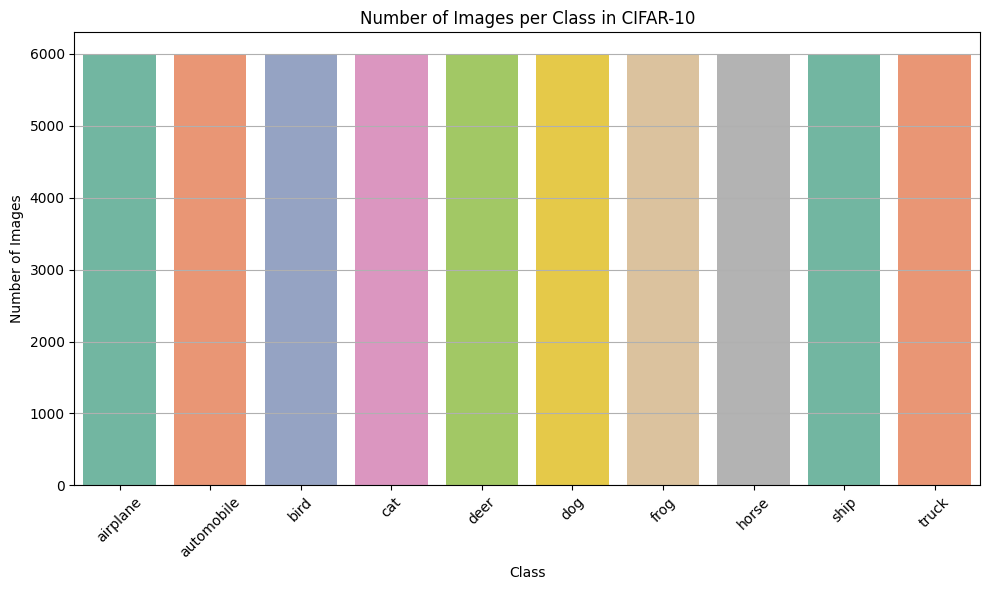

In [14]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

class_counts = pd.Series(y_all.flatten()).value_counts().sort_index()

class_distribution = pd.DataFrame({
    'Class': class_names,
    'Count': class_counts.values
})

plt.figure(figsize=(10,6))
sns.barplot(x='Class', y='Count', data=class_distribution, palette='Set2')
plt.title('Number of Images per Class in CIFAR-10')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [15]:
r_channel = x_all[:,:,:,0]
g_channel = x_all[:,:,:,1]
b_channel = x_all[:,:,:,2]

summary = {}
for color, channel in zip(['Red', 'Green', 'Blue'], [r_channel, g_channel, b_channel]):
    flat = channel.flatten()
    summary[color] = {
        'Mean': np.mean(flat),
        'Variance': np.var(flat),
        'Minimum': np.min(flat),
        'Maximum': np.max(flat)
    }

summary_df = pd.DataFrame(summary)
print("Statistical Summary for Each Color Channel:")
print(summary_df)

Statistical Summary for Each Color Channel:
                  Red        Green         Blue
Mean       125.426539   123.076746   114.030206
Variance  3966.185615  3851.962383  4449.705189
Minimum      0.000000     0.000000     0.000000
Maximum    255.000000   255.000000   255.000000


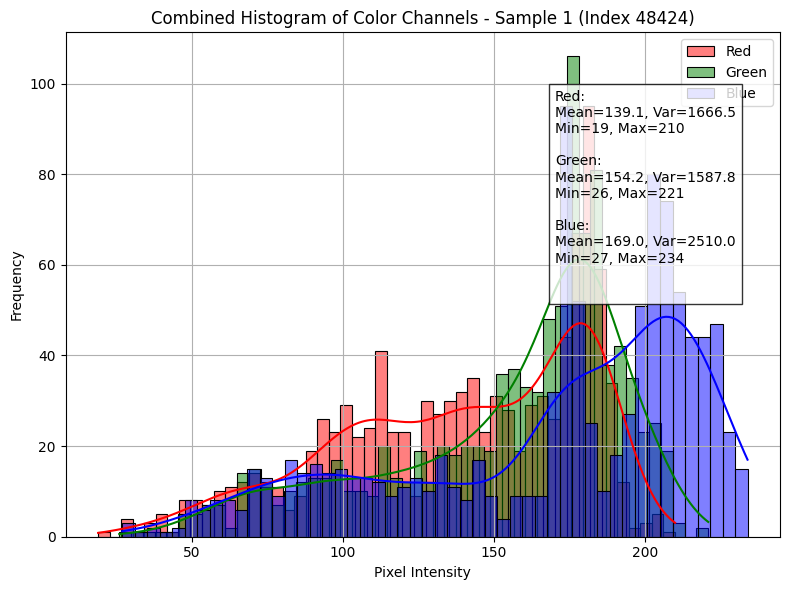

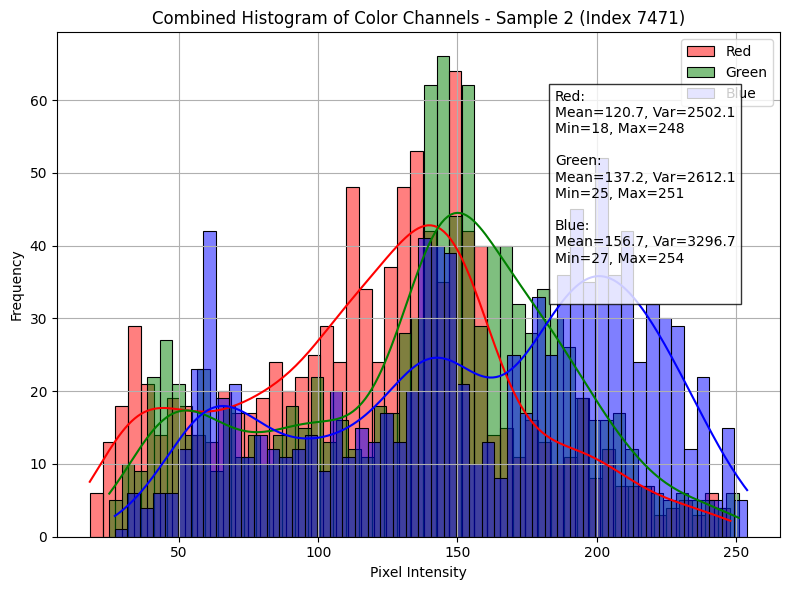

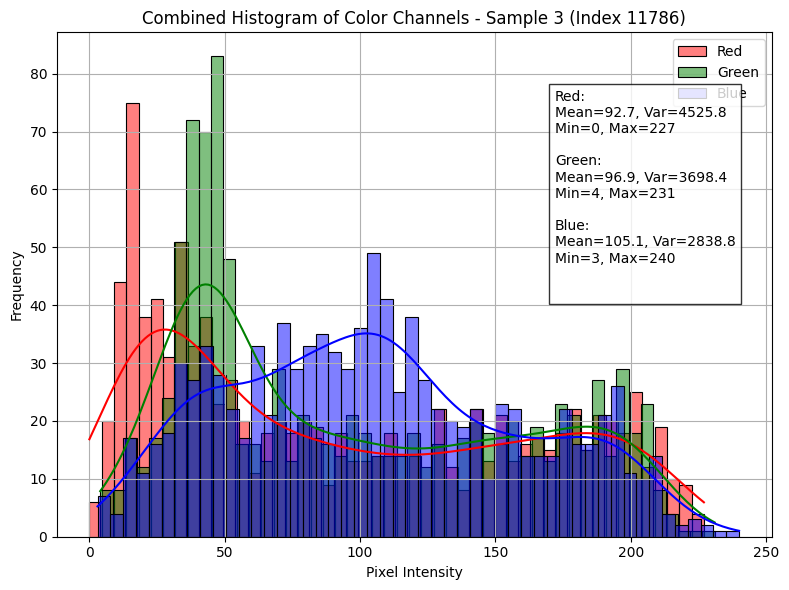

In [16]:
sample_indices = np.random.choice(len(x_all), size=3, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    img = x_all[sample_idx]
    plt.figure(figsize=(8,6))
    stats_text = ""
    colors = ['Red', 'Green', 'Blue']
    
    for i, color in enumerate(colors):
        channel_data = img[:,:,i].flatten()
        sns.histplot(channel_data, bins=50, color=color.lower(), kde=True, label=color, alpha=0.5)

        mean_val = np.mean(channel_data)
        var_val = np.var(channel_data)
        min_val = np.min(channel_data)
        max_val = np.max(channel_data)

        stats_text += f"{color}:\nMean={mean_val:.1f}, Var={var_val:.1f}\nMin={min_val}, Max={max_val}\n\n"

    plt.title(f'Combined Histogram of Color Channels - Sample {idx+1} (Index {sample_idx})')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.gcf().text(0.7, 0.5, stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

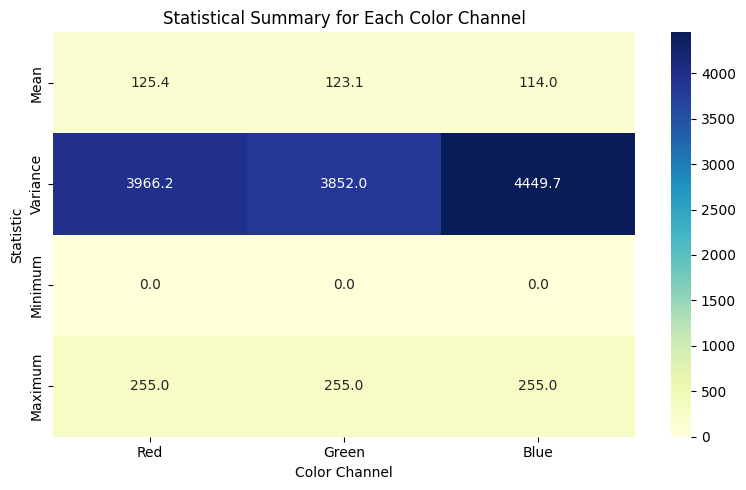

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(summary_df, annot=True, cmap="YlGnBu", fmt=".1f", cbar=True)
plt.title('Statistical Summary for Each Color Channel')
plt.xlabel('Color Channel')
plt.ylabel('Statistic')
plt.tight_layout()
plt.show()

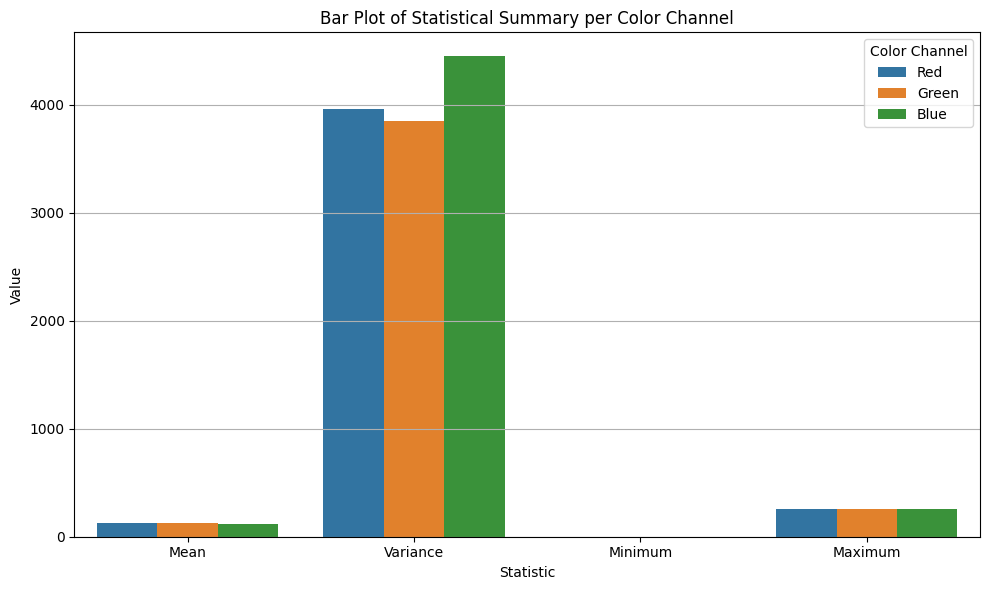

In [18]:
summary_melted = summary_df.reset_index().melt(id_vars='index')
summary_melted.columns = ['Statistic', 'Color Channel', 'Value']

plt.figure(figsize=(10,6))
sns.barplot(x='Statistic', y='Value', hue='Color Channel', data=summary_melted)
plt.title('Bar Plot of Statistical Summary per Color Channel')
plt.xlabel('Statistic')
plt.ylabel('Value')
plt.legend(title='Color Channel')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()